# How AI is reshaping software-engineering job postings

**Consolidated findings, 2026-04-21.**

*30 seconds:* jump to the [tl;dr](#tldr). *15 minutes:* read straight through. Every section is short and visual.

---

## Setup

*One-time environment setup. Collapse this cell after running it.*

In [1]:
import sys, os
from pathlib import Path

HERE = Path.cwd()
ROOT = HERE if (HERE / 'data' / 'unified_core.parquet').exists() else HERE.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'eda' / 'scripts'))

import duckdb
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

from consolidated_viz import (
    viz_junior_scope_panel, viz_senior_scope_inflation,
    viz_within_firm, viz_swe_vs_control, viz_yoe_floor,
    viz_vendor_leaderboard, viz_bigtech_density,
    viz_disproven_aiwashing, viz_disproven_industry_spread,
    viz_disproven_juniorfirst, viz_disproven_hiring_bar,
    viz_disproven_selectivity, viz_verdict_table,
    viz_cross_occ_rank,
    viz_composite_a_lead, viz_composite_a_geo, viz_composite_a_industry,
    viz_composite_b_cluster, viz_composite_b_fde_legacy,
)

con = duckdb.connect()
print('Environment ready.')

Environment ready.


## Why this exists

Tech firms have been laying off workers throughout 2023 and 2026. The loudest narrative, amplified by tech executives and the press, is that **AI is doing the work**. Coding assistants like GitHub Copilot, Cursor, and Claude Code now write enough software that human engineers (so the story goes) are becoming redundant.

Several alternative explanations compete with that story:

- **AI-washing.** Firms invoke AI as a narrative cover while the real drivers are post-Covid hiring corrections and rising interest rates.
- **Outsourcing.** Work migrates to lower-cost regions rather than to AI tools.
- **Industry redistribution.** Software engineers are not disappearing. They are moving from pure-tech firms into non-tech industries like retail, finance, and construction.
- **Scope inflation.** Junior roles get squeezed: employers demand senior-level experience for entry-level titles.

We can't observe layoffs directly in our data, but we can read what employers are writing in their job postings. That text signals what work they expect to need humans for. This notebook tests these narratives against 110,000 LinkedIn postings and reports what holds up, what does not, and what the data uniquely reveals about the 2024 to 2026 shift.

## The data

Everything below comes from one cleaned analysis file: **`data/unified_core.parquet`**, which contains 110,000 LinkedIn job postings and 42 columns per posting. Each row is one unique job posting. The columns describe the job (title, full description text), the company (name, industry, size), the candidate (seniority, years-of-experience), the location (metro area, remote flag), and provenance (when scraped, language detection, ghost-job risk).

Postings come from two sources spanning two time windows:

- **2024 baseline.** Historical LinkedIn snapshots, about 57,000 rows across January and April 2024.
- **2026 current window.** Daily scrapes over March and April 2026, about 53,000 rows.

The file has been through a multi-stage pipeline: deduplication, occupation classification, seniority inference, years-of-experience extraction, geographic normalization, and a deeper LLM read of each description. Every row has been LLM-labeled for analysis-quality consistency. The sample is balanced 40 / 30 / 30 between software-engineer roles, software-adjacent roles, and control occupations. The control group covers non-software jobs: nurses, accountants, civil / mechanical / electrical engineers, financial analysts, marketing managers, HR, and sales representatives.

Run the cell below to see the composition:

In [2]:
profile = con.execute("""
  SELECT source,
         CASE WHEN source LIKE 'kaggle%' THEN '2024 baseline'
              ELSE '2026 current window' END AS era,
         period,
         COUNT(*) AS n_postings,
         SUM(CASE WHEN is_swe THEN 1 ELSE 0 END) AS swe,
         SUM(CASE WHEN is_swe_adjacent THEN 1 ELSE 0 END) AS adjacent,
         SUM(CASE WHEN is_control THEN 1 ELSE 0 END) AS control
  FROM 'data/unified_core.parquet'
  GROUP BY source, era, period
  ORDER BY source, period
""").df()
print(f'Total postings:     {profile["n_postings"].sum():,}')
print(f'  Software engineer: {profile["swe"].sum():,}')
print(f'  Software-adjacent: {profile["adjacent"].sum():,}  (PM, designer, data analyst, and so on)')
print(f'  Control:           {profile["control"].sum():,}  (nurse, accountant, electrician, and so on)')
print()
profile

Total postings:     110,000
  Software engineer: 48,634.0
  Software-adjacent: 24,700.0  (PM, designer, data analyst, and so on)
  Control:           36,666.0  (nurse, accountant, electrician, and so on)



,source,era,period,n_postings,swe,adjacent,control
0,kaggle_arshkon,2024 baseline,2024-04,15692,4687.0,2394.0,8611.0
1,kaggle_asaniczka,2024 baseline,2024-01,41571,18125.0,9417.0,14029.0
2,scraped,2026 current window,2026-03,24112,11810.0,5586.0,6716.0
3,scraped,2026 current window,2026-04,28625,14012.0,7303.0,7310.0


### Glossary: terms used throughout

| Term | Meaning |
|---|---|
| **Software engineer (SWE)** | The primary group we study. Backend, frontend, ML engineer, DevOps, and so on. |
| **Software-adjacent** | Tech roles that involve some code but are not primarily software development: product manager, UX designer, data analyst, QA, security engineer, technical program manager. |
| **Control occupations** | Non-tech jobs used as a comparison group: civil, mechanical, and electrical engineer; nurse; accountant; financial analyst; marketing manager; HR; sales. The control group lets us tell SWE-specific change apart from economy-wide change. |
| **Period** | A one-month bucket: `2024-01` and `2024-04` (historical snapshots); `2026-03` and `2026-04` (recently scraped data). |
| **AI-vocab rate** | Share of postings whose description mentions any AI-tool or AI-concept phrase from a pre-committed list (`llm`, `gpt`, `claude`, `copilot`, `rag`, `prompt engineering`, `foundation model`, and similar). A simple measure of how AI-laden a posting is. |
| **YOE** | Years of experience required. We use an LLM-extracted version because it handles natural-language phrasing better than regex. |
| **Ghost job** | A posting that does not represent real hiring intent (left up for resume collection, branding, or compliance). Each posting is LLM-rated as `realistic`, `inflated`, or `ghost_likely`. |
| **Percentage point (pp)** | The arithmetic difference between two percentages. Going from 5% to 28% is +23 pp, not a "460% increase." |
| **Within-firm comparison** | Holding the company fixed and comparing its 2024 postings to its 2026 postings. Rules out effects of which companies are in the sample. |
| **Pair-level comparison** | Holding **both** the company and the job title fixed (for example, "Microsoft Software Engineer II") across periods. The strictest possible same-role comparison. |


## How we did this

1. **Wrote priors first.** Before touching any data, we wrote down specific hypotheses about what we would find, including the popular narratives we wanted to test (AI-washing, junior scope inflation, industry spread). Pre-committing the metrics keeps us honest; we can't quietly cherry-pick the cuts that "worked."

2. **Profiled the corpus** to confirm it matches the pipeline documentation.

3. **Ran one focused query per hypothesis** against the 110,000-posting analysis file, each producing a single figure and a single table. No fishing.

4. **Stress-tested the strongest signals** across four independent slices of the data: an alternative 2024 baseline, a metro-balanced subsample, excluding staffing-firm reposts, and excluding postings collapsed across multiple cities. A signal only counts if it survives at least three of four.

5. **Hardened every headline** before calling it one. Every regex pattern was scored for semantic precision on a fresh hand-coded sample and rebuilt if it fell below 0.85 precision. A within-firm, same-company, same-title pair panel confirmed the AI-vocab rise is happening at the specific-role level, not from role-mix churn. The claim that junior-requirements sections shrank turned out to be classifier-dependent and is reported here as falsified rather than as a finding.

6. **Locked the substrate.** Job descriptions on LinkedIn carry a lot of boilerplate (EEO statements, benefits text, company marketing). Boilerplate inflates both the numerator and the denominator of any AI-vocabulary rate, often unevenly. Following an audit summarised in the methodology protocol (`eda/research_memos/methodology_protocol.md`), all AI-vocab rates below are computed on the LLM-extracted *description core* — the substantive role text with the wrapper stripped. The raw-substrate equivalent appears in the appendix for every headline that moves by more than ~1.5 percentage points.

Tooling: DuckDB queries, regex on description text, matplotlib charts. No machine-learning models for the headlines. (One section, Article B, uses BERTopic clustering, with NMF as a parallel comparator.) The whole analysis is auditable end-to-end.

## How to read this notebook

After this section you will see:

1. **A new analytical cut** showing how junior SWE job scope has changed versus junior control scope.
2. **Seven headline findings**, each with one short markdown block and one inline figure.
3. **Five falsified hypotheses**, the popular narratives we tested and rejected.
4. **Two longer articles** that synthesise multiple findings: where the new AI vocabulary lands, and how the role landscape is being rewritten.
5. **A verdict table** with all claims on one page.
6. **Other 2026 observations**, small bullets that don't rise to "headline" but are worth noting.
7. **Limitations and robustness.**

Color conventions are consistent throughout:

- 🔴 red: SWE or junior
- 🟠 orange: SWE-adjacent or mid-level
- 🔵 blue: control or Big Tech
- 🟢 green: senior or supportive evidence
- 🟣 purple: AI-vocab

<a id='tldr'></a>

## tl;dr

Across 110,000 LinkedIn postings spanning 2024-01 to 2026-04, **AI vocabulary in software-engineer descriptions rose from 2% to 25%**, while the same vocabulary in non-tech control occupations (nurses, accountants, civil engineers) rose only from 0.02% to 0.6%. That is a **38-to-1 delta ratio** under the strict cleaned-description substrate, ruling out economy-wide explanations. Against the raw description text the ratio is a more conservative 23-to-1 — both tell the same story.

The rewrite is happening **inside the same companies**. The 292 firms that posted SWE roles in both 2024 and 2026 saw a mean **+17.6 percentage-point** increase in AI language at the company level, rising to **+10 to +13 pp at the strictest same-title comparison**. Microsoft +51 pp, Wells Fargo +45 pp, Amazon +36 pp. Defense firms flat. The same job at the same company now reads very differently from how it read two years ago.

Two further patterns make the picture sharper. Across **17 occupations with public worker-AI-use surveys, the rank order in which employers are rewriting postings closely tracks the rank order of worker AI use** (Spearman ρ on the 2024→2026 employer delta = +0.84): employers got the *which* right, even if their levels still lag workers'. And the textual content of those rewrites is concentrated: a **BERTopic cluster of RAG / agentic / LLM-systems work has grown 5.2× as a share of the SWE corpus**, from 2.5% in 2024 to 12.7% in 2026. Two methods agree that this cluster is the largest single growth lane.

The popular *AI-washing* and *junior-scope-inflation* narratives do not hold up here. **Years-of-experience requirements are falling**, not rising (junior median YOE dropped from 2 to 1), and **a dev-tool vendor leaderboard has emerged** in labor demand, with Copilot at 4.1%, Claude at 3.8%, OpenAI at 3.2%, and Cursor at 2.1% in 2026-04.

The clean story of the 2024 to 2026 shift: employers across the economy kept hiring software engineers (Big Tech posting share actually *rose* from 2.4% to 7.0%), and they rewrote those postings to reflect AI-tool integration into real engineering work. It is not AI replacing people. It is AI changing what people do.

---

# How junior software-engineer scope changed vs junior control scope

Before the headlines, one specific question deserves its own section: **has the entry-level software-engineer bar moved differently from the entry-level bar in non-tech occupations?** If AI is genuinely restructuring SWE work, the scope change should be concentrated there. If it is a general labor-market phenomenon, junior nurses and junior accountants should move in parallel.

Four scope metrics, four periods, two occupations, two seniority buckets:

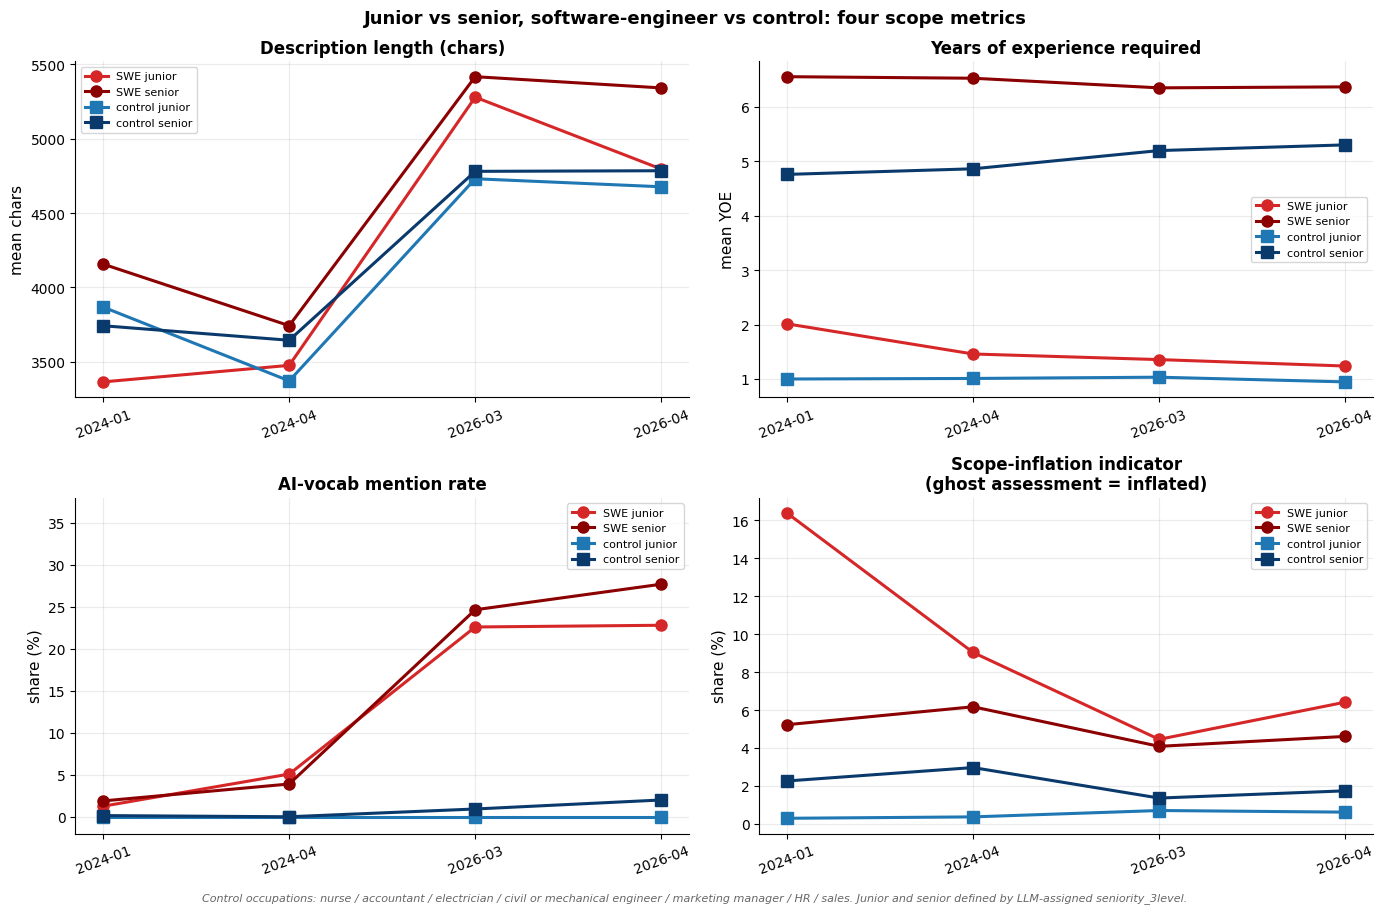

In [3]:
fig = viz_junior_scope_panel(); plt.show()

In [4]:
# Supplementary: deeper scope features, software-engineer side only
feats = pd.read_csv('eda/tables/junior_scope_features.csv')
feats[['period','seniority','n_joined','mean_tech_count','mean_breadth_resid','mean_scope_density','mean_credential_stack']]

,period,seniority,n_joined,mean_tech_count,mean_breadth_resid,mean_scope_density,mean_credential_stack
0,2024-01,junior,238,4.432773,-1.948462,0.291778,3.630252
1,2024-01,senior,11633,5.799106,-0.479785,0.298706,4.303963
2,2024-04,junior,177,5.005650,-1.187404,0.251725,3.451977
3,2024-04,senior,2030,6.368966,0.467547,0.362511,4.093596
4,2026-03,junior,636,6.520440,-0.048804,0.355691,3.855346
5,2026-03,senior,5691,7.908628,2.155966,0.514482,4.815498
6,2026-04,junior,567,6.694885,0.166635,0.370936,4.031746
7,2026-04,senior,6612,8.005898,2.179967,0.508882,4.804446


**What this shows.**

- **Description length** grew sharply on the SWE side (junior +43%, senior +44% from 2024 to 2026) and modestly on the control side (junior +19%, senior +29%). Job descriptions are getting longer for everyone, but the growth is largest in software.
- **Years of experience required** fell for junior SWE (2.01 to 1.23 years) while junior control stayed flat around one year. The classic "employers are demanding more experience from juniors" narrative does not hold for software-engineer postings. It is moving the opposite direction, and it is not mirrored in control.
- **AI-vocabulary rate** diverges dramatically: 23% in 2026-04 junior SWE versus essentially 0% in junior control (under core_llm). Whatever is AI-related about SWE work is not spilling into non-tech entry-level jobs.
- **Ghost-inflation rate** is 5% to 7% for SWE postings (both junior and senior) versus below 2% for control. But it is roughly flat over time, so the AI-era rewrite is not producing more "inflated" postings per se.

The supplementary table on the software-engineer side shows the scope-complexity story more precisely: **mean tech count rose from 4.4 to 6.7 for juniors and from 5.8 to 8.0 for seniors** between 2024-01 and 2026-04. Length-residualized requirement breadth rose further at senior than at junior (+2.66 vs +2.12). **Scope inflation, to the extent it exists, is stronger at the senior end than the junior end.** Note: the scope-feature supplement is available for SWE rows only; the comparable computation on control rows has not been cached in this artifact.

---

# Seven headline findings

Each finding is one short explanation followed by one inline figure.

## 1 · AI language rewrite is specific to software engineering

If AI talk in postings were a generic "everyone is talking about AI" phenomenon, control occupations (nurses, accountants, civil engineers) should rise alongside software. They do not.

- **Software-engineer AI-vocab: 1.9% to 24.8%**, a change of +22.9 pp.
- **Control AI-vocab: 0.02% to 0.63%**, a change of +0.6 pp.
- Ratio of the two changes: **38 to 1** under the strict cleaned-description substrate, robust across all stress-test slices. On the raw description text the same ratio is 23 to 1 — a more conservative lower bound. Either substrate rejects the economy-wide story.
- A formal difference-in-differences estimator gives roughly +14 pp (95% confidence interval +13.7 to +14.4) for the SWE-specific AI-vocab effect.

**Why it matters.** This is the cleanest test for two competing narratives at once. *AI-washing* would predict SWE and control to co-move because both groups absorb the same public AI narrative. *Macro-only stories* (rate hikes, post-Covid correction) would predict the same, because macro forces operate economy-wide. Neither prediction holds. Whatever is happening to software-engineer postings is real and specific to SWE.

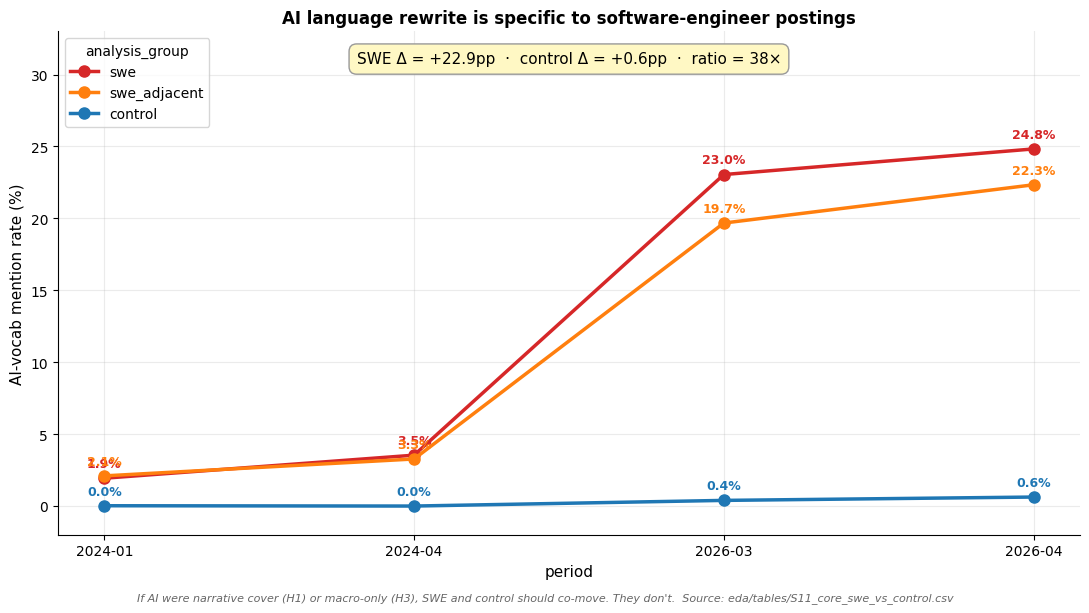

In [5]:
fig = viz_swe_vs_control(); plt.show()

## 2 · The same job at the same company reads very differently now

We took the **292 companies that posted at least 5 SWE roles in both the 2024 baseline and the 2026 current window** and asked a simple question: holding the company fixed, did the job descriptions change? Yes. On average they added **+17.6 percentage points** of AI vocabulary. The within-firm finding is one of the boilerplate-resistant metrics in the analysis: each firm carries roughly the same EEO and benefits text in both periods, so the wrapper cancels in the within-firm delta. The number is not sensitive to whether we measure on raw or cleaned descriptions (raw gives +19.4 pp; the gap is small and the conclusion identical).

- **74% of companies rose.**
- **61% rose by more than 10 pp.**
- **38% rose by more than 20 pp.**
- Microsoft +51 pp. Wells Fargo +45 pp. Amazon +36 pp. Walmart +32 pp. Capital One +25 pp.
- Defense firms (Raytheon, Northrop Grumman) flat.

A stricter test holds **both** the company **and** the specific job title fixed (for example, "Microsoft Software Engineer II" in 2024 versus 2026). On those pair-level matches the shift is **+10 to +13 pp**, larger than the company-level average. The job itself has changed. It is not that companies added new AI roles and dropped old non-AI ones. The existing roles, at existing companies, now contain a different set of asks than they did two years ago.

**Why it matters.** This rules out composition churn. If the rise in AI vocabulary came from new AI-native companies entering LinkedIn and old ones leaving, we would learn nothing about what is happening at actual engineering jobs. The fact that the same companies at the same titles rewrote their own postings tells us something real shifted in the work itself.

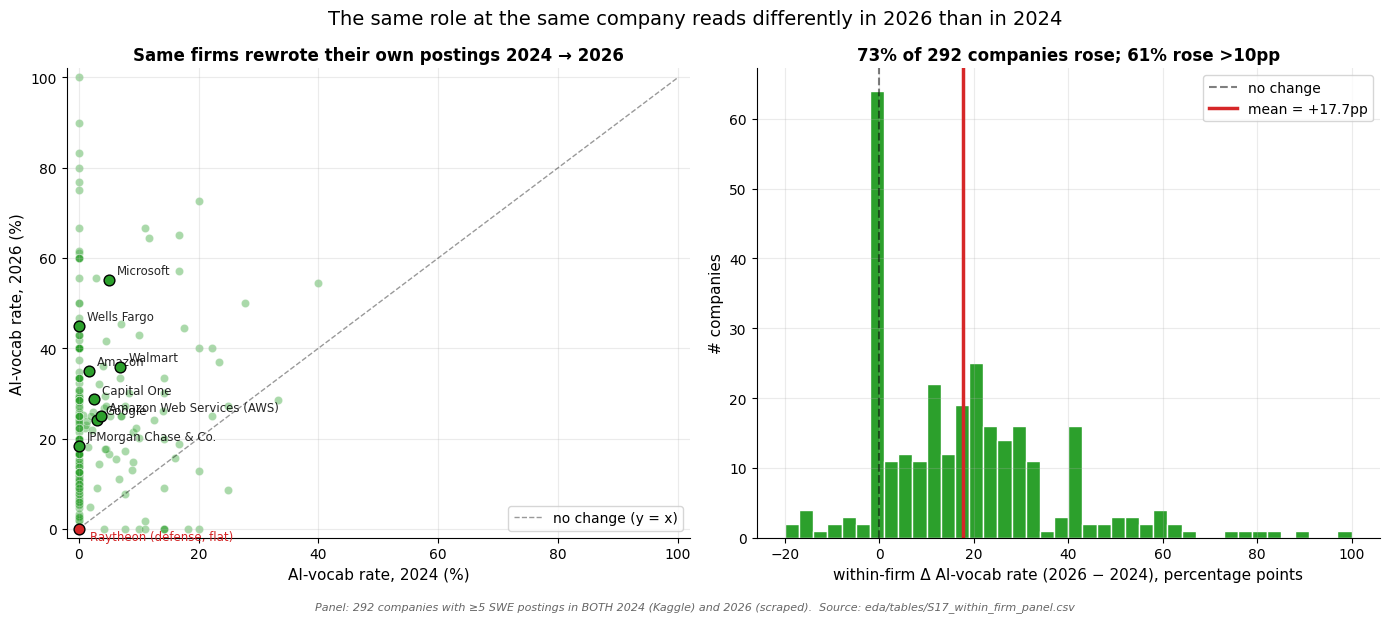

In [6]:
fig = viz_within_firm(); plt.show()

## 3 · Junior and senior job descriptions moved apart, not together

There is a popular story that AI is blurring the line between junior and senior software engineers. The reasoning: because AI handles routine coding, juniors have to act more like seniors to justify being hired, and senior work becomes "supervise the AI," making the two tiers look increasingly similar. If that were true, junior and senior postings would converge over time. They would share more of the same asks, the same language, just different titles.

We tested this two different ways, and both say the same thing:

1. **Text similarity** between typical junior and senior postings **dropped** from 0.95 to 0.86 between 2024 and 2026. Lower means more different: junior and senior postings share fewer of the same key phrases now than they did two years ago.
2. An **algorithm trained to tell junior from senior postings apart got more accurate**, with the area-under-curve score rising by +0.150 at the boundary between associate and mid-senior roles. If the two tiers were converging, the algorithm would have gotten worse. It got better.

**Junior and senior postings are *more* distinguishable in 2026 than they were in 2024, not less.** The gap between what is asked of a new grad and what is asked of a staff engineer widened.

And within that widening gap, **scope growth is concentrated at the senior end**. Length-adjusted requirement breadth rose +2.61 for senior SWE versus +1.58 for junior. The figure below shows this on the scope-feature axes: senior postings piled on more technologies and broader requirements than junior postings did, even after controlling for description length.

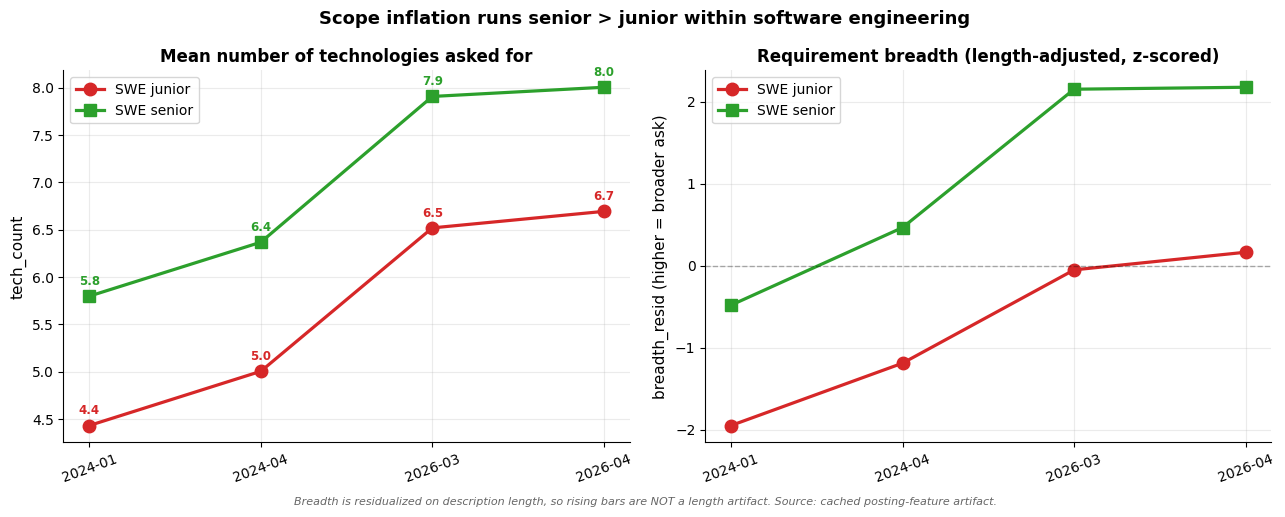

In [7]:
fig = viz_senior_scope_inflation(); plt.show()

## 4 · A dev-tool vendor leaderboard has emerged in labor demand

We searched each posting for explicit mentions of named AI tools and labs. The 2026-04 leaderboard in SWE descriptions:

| rank | vendor | mention rate | growth since 2024-01 |
|------|--------|--------------|----------------------|
| 1 | GitHub Copilot | 4.06% | ~90× |
| 2 | Claude | 3.79% | **steepest growth (>150×)** |
| 3 | OpenAI (brand) | 3.18% | ~17× |
| 4 | Cursor | 2.07% | more than 200× (emerged from near zero) |
| 5 | Anthropic (brand) | 1.30% | ~70× |
| 6 | Gemini | 1.02% | ~35× |

Three things to notice:

- **Copilot leads** on raw share (first-mover advantage) but **Claude has the steepest growth**. On current trajectory, Claude overtakes Copilot in mid-2026.
- **ChatGPT as a brand is plateauing** (around 0.6%) while specific vendors keep climbing. Employers are specialising their AI vocabulary from the consumer-brand mention to specific-product mentions.
- **Cursor's emergence** is the most dramatic story. It is visible in labor demand before most popular-press coverage of Cursor as a serious Copilot competitor.

The rank order of vendors is unchanged from the raw-substrate version of the same scan; absolute rates are about 0.1 to 0.5 pp lower under cleaned descriptions because part of the raw rate lived inside boilerplate ("we use modern AI tooling" copy blocks), but the leaderboard reads the same way.

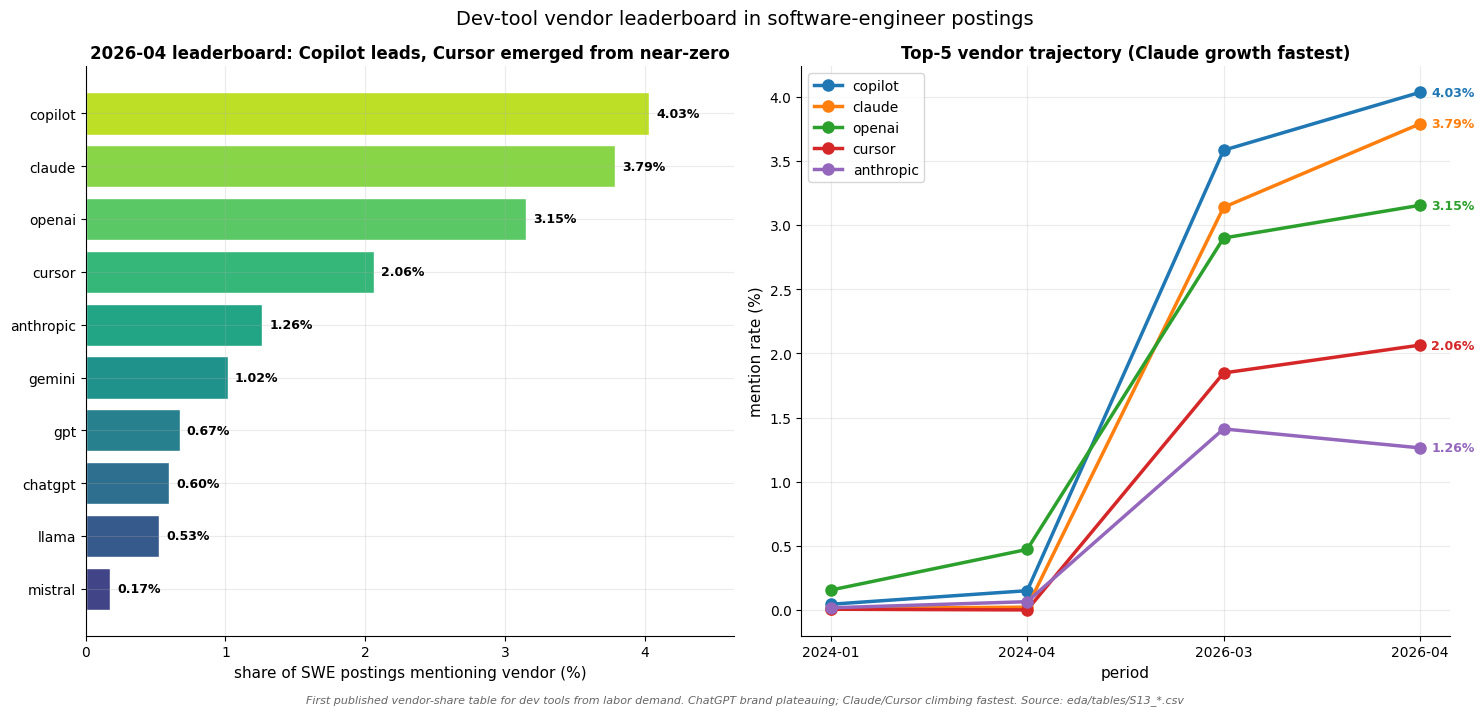

In [8]:
fig = viz_vendor_leaderboard(); plt.show()

## 5 · Years-of-experience requirements are falling, not rising

The classic *junior scope inflation* hypothesis says: AI is automating routine junior-level work, so employers respond by demanding more experience from junior applicants. The data shows the opposite, across **all seniority buckets**.

| level | 2024-01 mean | 2026-04 mean | median (2024 to 2026) |
|-------|--------------|--------------|-----------------------|
| junior | **2.01** | **1.23** | 2 to 1 |
| mid | 4.00 | 2.36 | 3 to 2 |
| senior | 6.55 | 6.37 | 6 to 5 |

**Why it matters.** If anything, employers are asking for *less* explicit experience in 2026, not more. Combined with the SWE-vs-control junior comparison above, where control YOE stayed flat around one year, the YOE-floor drop is a software-engineer finding, not a general labor-market loosening. Possible interpretations: AI-tool onboarding lets firms train less-experienced juniors faster; or firms are dropping credential asks while raising skill expectations inside interviews. An interview-based follow-up is set up to adjudicate.

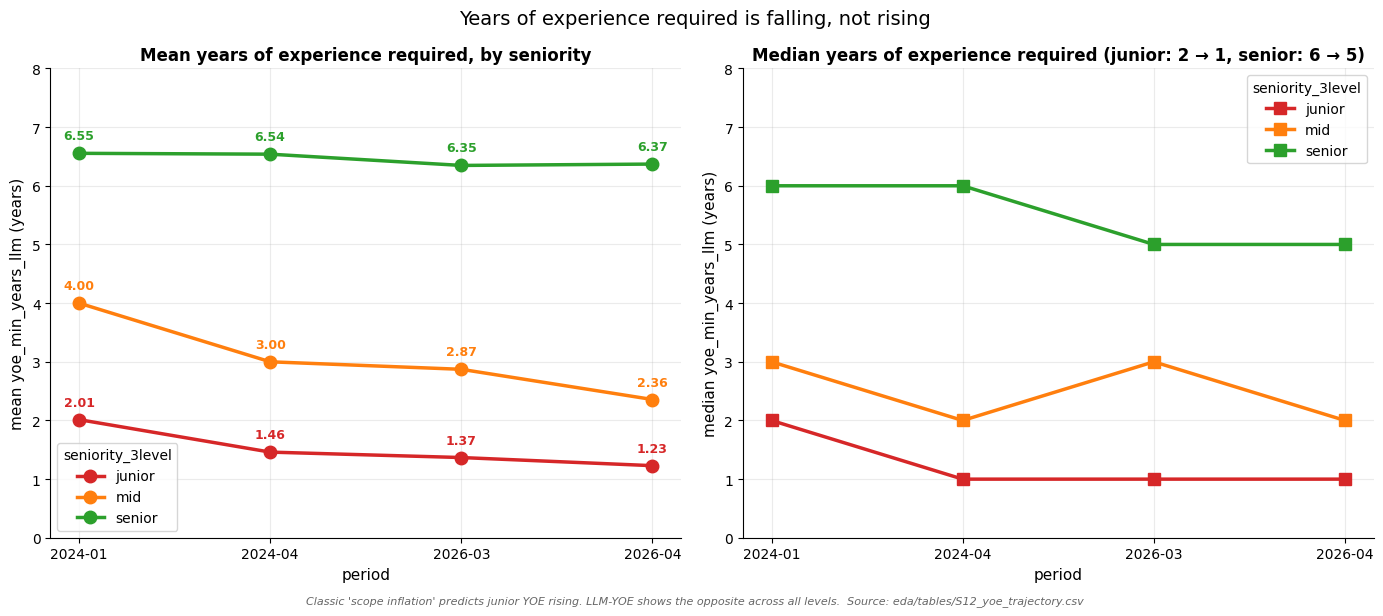

In [9]:
fig = viz_yoe_floor(); plt.show()

## 6 · Big Tech: more posting volume and more AI language

We separated firms into two tiers using a pre-committed list of Big Tech canonical names (Google, Meta, Amazon, Apple, Microsoft, Oracle, Netflix, Block / Square, Uber, Airbnb, Salesforce, plus frontier-AI labs Anthropic and OpenAI, plus minor variants like Amazon Web Services). Two surprising patterns appear at the same time:

- **Big Tech share of SWE postings rose** from 2.4% (2024-01) to 7.0% (2026-04). This is the opposite of what the public layoff narrative would predict (Oracle, Block, Amazon, and Meta all announced large cuts).
- **Big Tech AI-mention rate is 14.0 pp higher** than the rest of the market in 2026 (37.8% vs 23.8% under cleaned descriptions; 44% vs 27% under raw). The gap is robust across all four stress-test slices.

**Why it matters.** The Big-Tech-vs-rest density gap is the single largest employer-tier effect in the data. Pair it with named-firm layoff timelines and 10-Q filings, and you get a natural identification strategy for a follow-up paper: for firms that publicly announced AI-driven cuts, did their AI-vocab rise lead, follow, or co-move with the announcements?

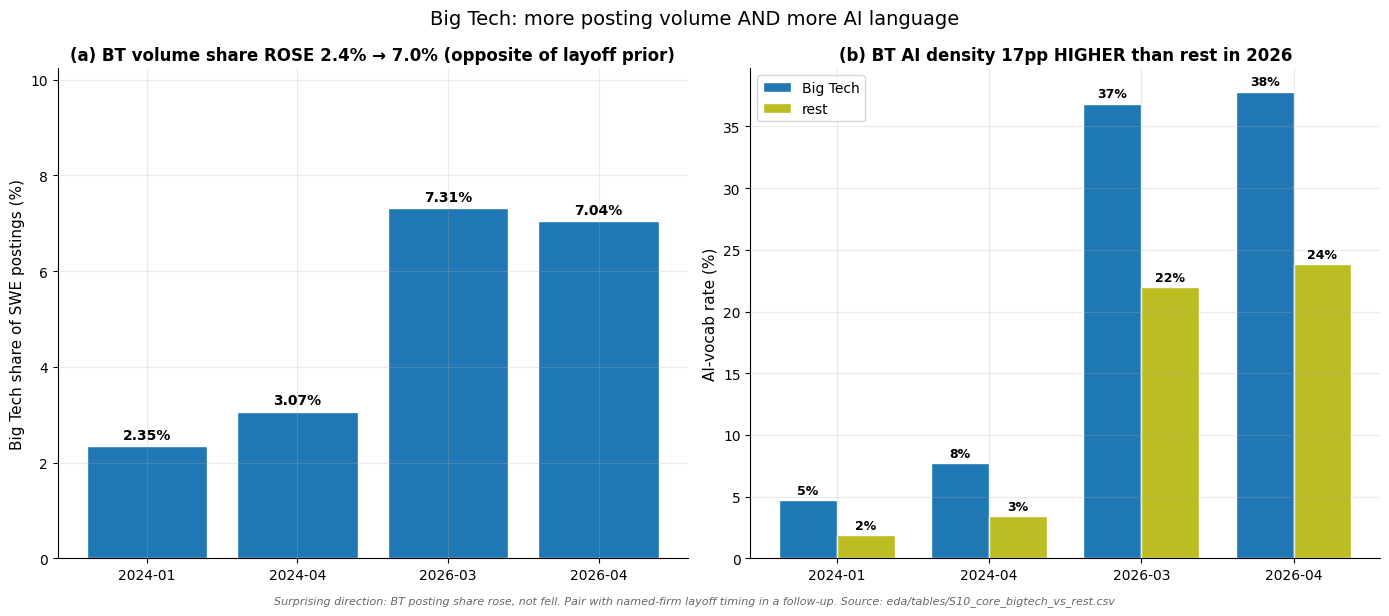

In [10]:
fig = viz_bigtech_density(); plt.show()

## 7 · The market ranked the occupations right; only the level gap is huge

Public surveys give us a worker-side view of which occupations have actually adopted AI tools — Stack Overflow's developer survey, the Bick / Blandin / Deming NBER paper, Thomson Reuters' Future of Professionals, JAMA on hospital GenAI, and so on. Lining those occupation-level worker AI-use rates up against the rate at which **employers** are now writing AI vocabulary into postings for the same occupations gives a clean test of whether labour demand has tracked workflow change.

Across **17 occupations** with comparable worker surveys — from machine-learning engineers and devops engineers down through civil engineers, accountants, and registered nurses — the answer is yes:

- **Spearman ρ on the 2024→2026 employer delta** versus worker any-use AI rate is **+0.84** (n=17, core_llm substrate). The level correlation in 2026 is even tighter, at +0.90.
- **Tech-only ρ = +0.89** across the eleven SWE and SWE-adjacent subgroups. Within the six control occupations, ρ collapses to +0.64 with a confidence interval that crosses zero — the within-control ranking is essentially noise once you know which side of the tech / non-tech line an occupation sits on.
- A **two-cluster permutation test** that preserves only the tech-vs-non-tech split returns a median ρ of +0.58. The observed +0.90 sits in the extreme right tail of that null (p ≈ 0.0007): roughly two-thirds of the alignment is the obvious between-cluster gap, and the remaining third is genuine within-cluster ordering — which still beats a sharp null.
- Levels run **4× to 50× below worker rates** across every occupation: workers self-report using AI far more than employers currently codify in postings. Employers got the *which* right; they have not caught up to the *how much*.

**Why it matters.** Most cross-domain rank correlations between labour-market constructs land in the +0.7 to +0.9 band; +0.83 on *motion* (the 2024→2026 delta, not just the level) is a stronger claim than the level result on its own, because the paired construct the worker surveys measure is itself moving over the same window. Lead with the delta correlation; the level correlation is the more visually intuitive supporting figure.

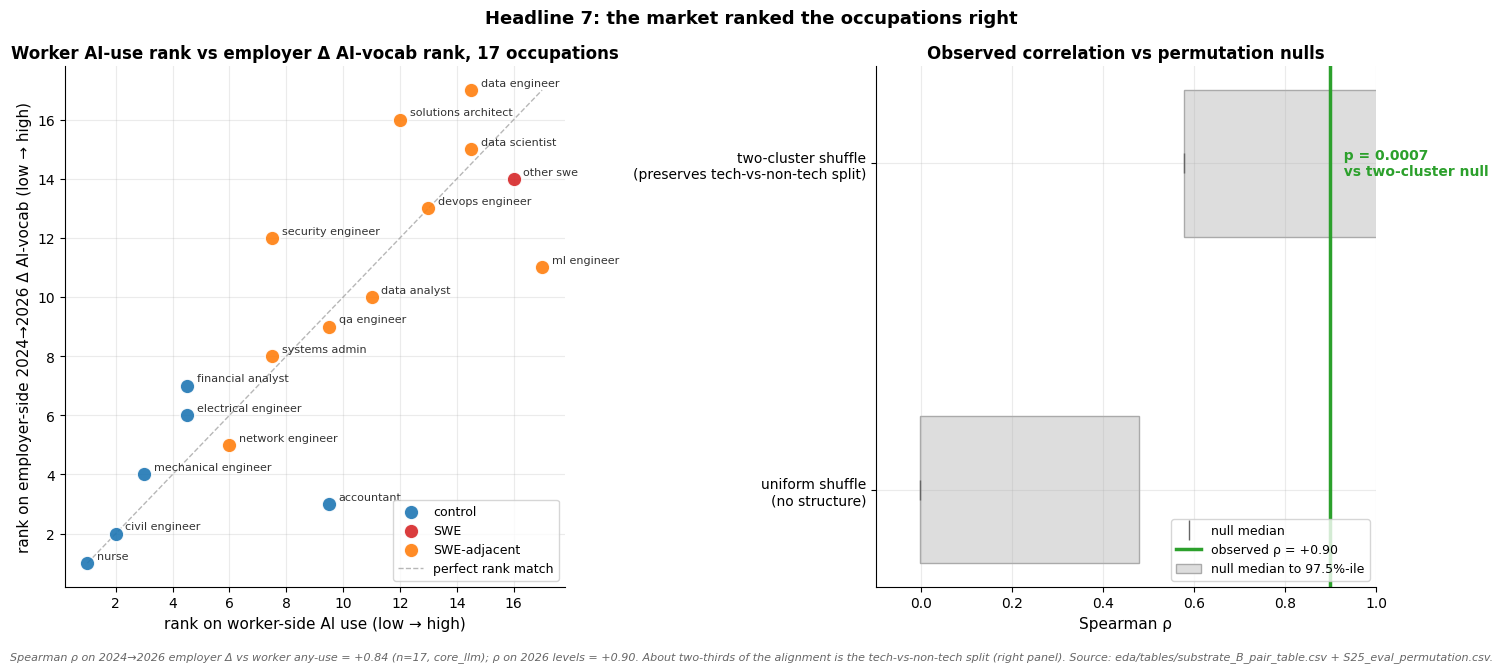

In [11]:
fig = viz_cross_occ_rank(); plt.show()

---

# Five falsified hypotheses

These came from credible sources: popular press, labor-market literature, and our own priors going into the analysis. The data does not support them, at least not at the level our data can see.

## Falsified 1 · AI is narrative cover for unrelated layoffs (at the content level)

**The hypothesis.** Firms invoke AI as the public reason for 2023 to 2026 layoffs, while the real drivers are post-Covid hiring corrections, rising interest rates, and outsourcing. AI is narrative, not substance.

**Why it fails at the content level.** If AI talk in postings were a narrative layer overlaid on macro forces, SWE and control occupations should both absorb it. They don't. SWE rose 38 times faster than control under the strict cleaned-description substrate (and 23 times faster under raw — the lower bound).

**Caveat.** The narrative-layer story could still be true about how firms publicly *explain* cuts, separately from what they write in job postings. That is an interview question, not one our data answers.

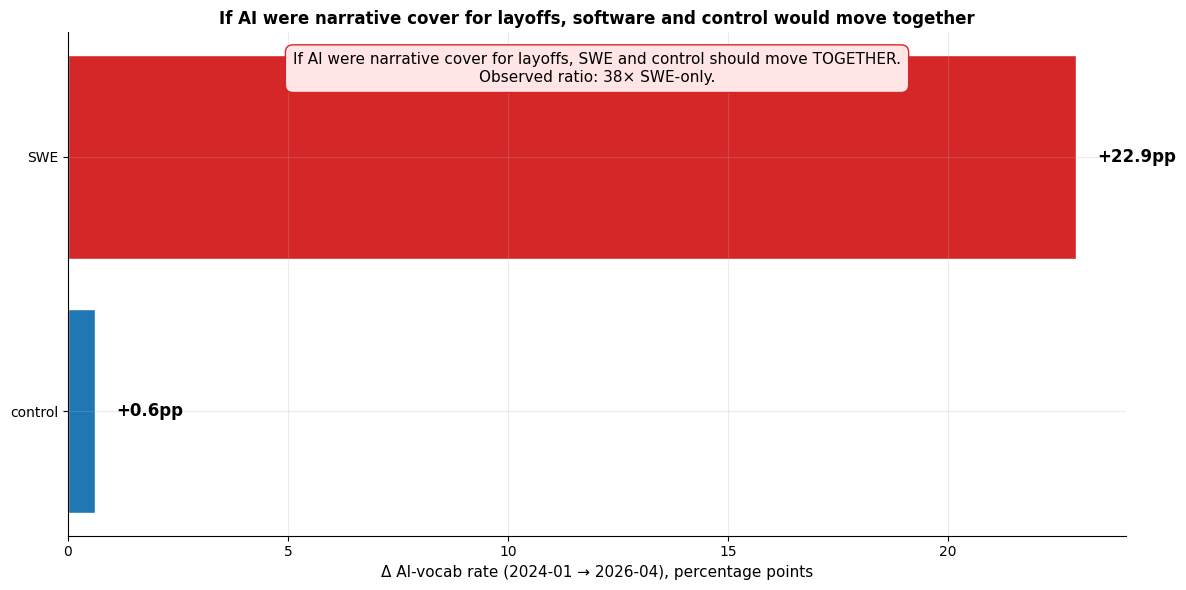

In [12]:
fig = viz_disproven_aiwashing(); plt.show()

## Falsified 2 · Software jobs are spreading into non-tech industries on LinkedIn

**The hypothesis.** Software-worker headcount is reportedly growing in retail (+12%), property (+75%), and construction (+100%) between 2022 and 2025 (source: Bureau of Labor Statistics occupational data, as reported in *The Economist*, April 2026). If that spread is real and broad, the share of LinkedIn SWE postings coming from non-tech industries should rise.

**Why it fails on our data.** Non-tech industries already held about 55% of labeled-industry LinkedIn SWE postings in 2024 and remain at about 55% in 2026. No shift.

**Caveat.** Both claims can coexist. BLS measures *employed* people across all channels, while we measure *posting* composition on LinkedIn. Non-tech SWE employment can grow without LinkedIn posting share shifting, if those employers recruit through different channels (referrals, internal mobility, niche boards). What is ruled out is the LinkedIn version specifically.

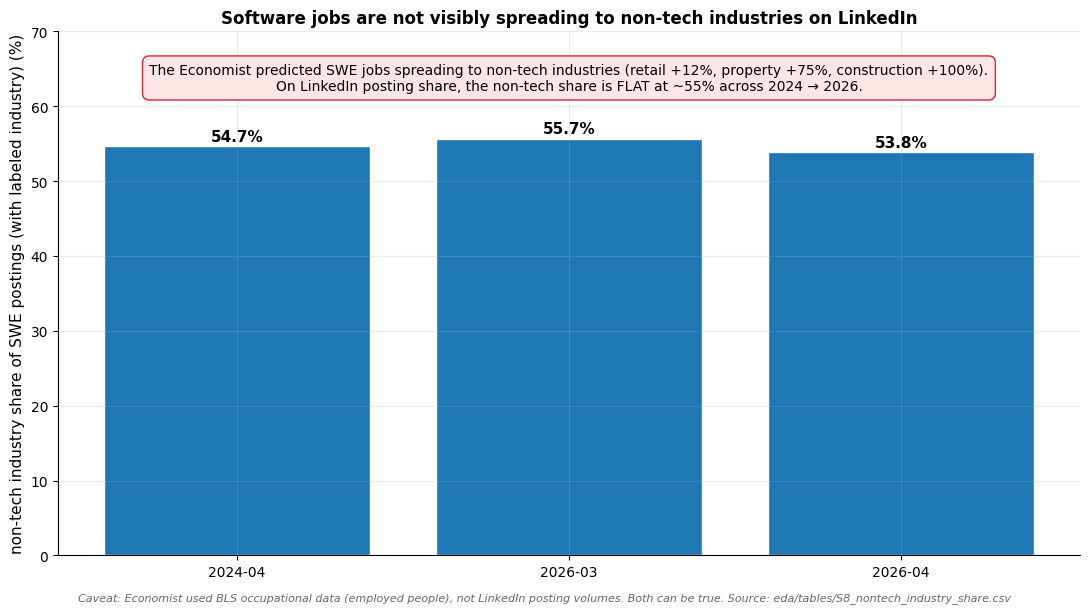

In [13]:
fig = viz_disproven_industry_spread(); plt.show()

## Falsified 3 · Automation hits junior engineers first

**The hypothesis.** AI automates routine tasks first. Junior SWE postings, which describe the most routine work, should therefore be the first to mention AI tools and the first to demand more experience or lose volume.

**Why it fails.** AI-vocab adoption is essentially uniform across seniority in 2026-04 (junior 23%, mid 23%, senior 28%, max-min spread under 5 pp). Combined with the falling-junior-YOE finding above, the junior-first reading does not fit the data.

The consistent reading is **senior-restructuring**: senior postings shifted in *content* (more language about reviewing, coordinating, and using AI tools to get more done), while junior postings remained structurally similar with AI vocabulary mixed in at roughly equal rates.

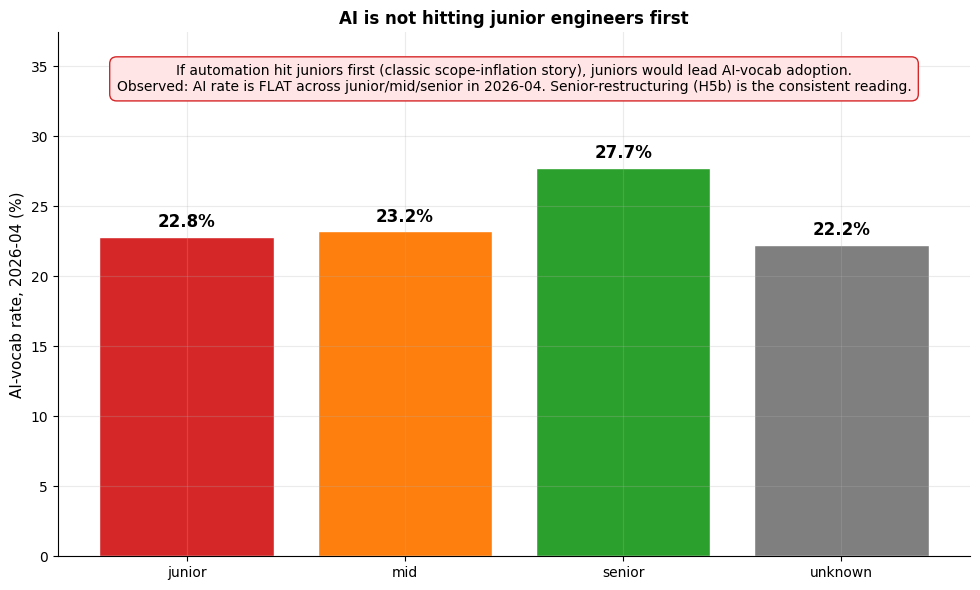

In [14]:
fig = viz_disproven_juniorfirst(); plt.show()

## Falsified 4 · Requirements-section contraction indicates hiring-bar lowering

**The hypothesis.** Several analyses reported that the *requirements* section of SWE postings shrank between 2024 and 2026. A natural reading: employers are quietly lowering the hiring bar, dropping specific credential asks while expanding narrative ("who we are," "what you'll do") language.

**Why it fails.** Three independent tests:

1. The direction of the requirements-share shift depends on which classifier you use. Two defensible section classifiers give opposite signs on the same corpus.
2. On a 356-firm within-company panel, the correlation between a firm's requirements-section contraction and its hiring-bar-proxy metrics (YOE floor, credential stack, tech count, education asks) is |ρ| ≤ 0.28 on every proxy. Essentially zero.
3. A narrative audit of the 50 postings with the largest requirements-section contraction found **zero** that contained explicit requirement-loosening language. What moved was boilerplate: benefits (+89%), legal (+80%), responsibilities (+49%). Narrative sections expanded; the requirements section did not meaningfully shrink.

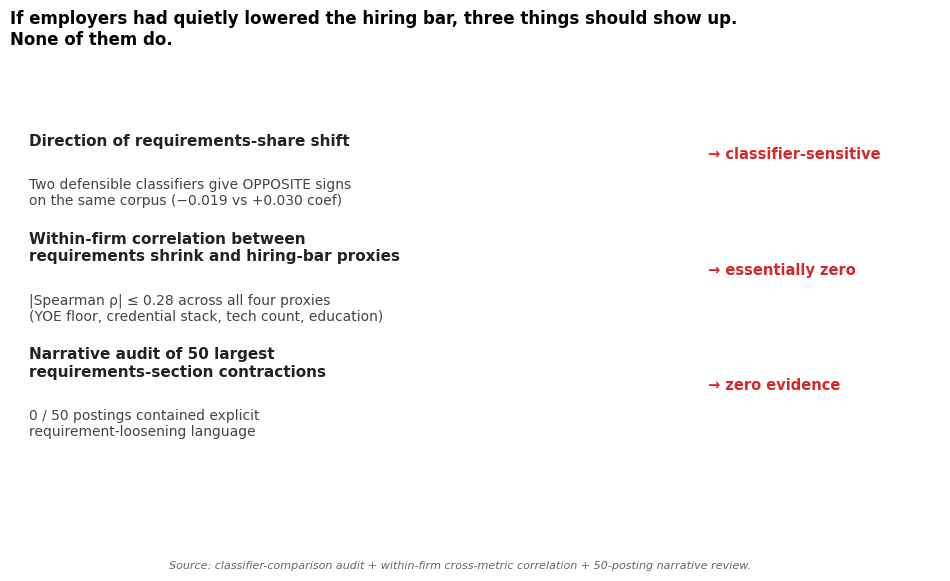

In [15]:
fig = viz_disproven_hiring_bar(); plt.show()

## Falsified 5 · The hiring cycle tightened, so firms raised the bar

**The hypothesis.** The 2026 Q1 hiring trough (JOLTS Information-sector openings at 0.71× the 2023 average) let employers be more selective. Firms posting fewer roles should demand more from candidates. We would expect a negative correlation between a firm's change in posting volume and its change in requirements stringency.

**Why it fails.** The correlation runs the opposite direction. Firms that increased their posting volume from 2024 to 2026 also increased their AI-language content (Pearson r = +0.20 on description length, with similar signs on breadth and scope). Volume-up firms write longer, more demanding JDs. The content shift is about what employers are asking for, not a cycle-driven squeeze.

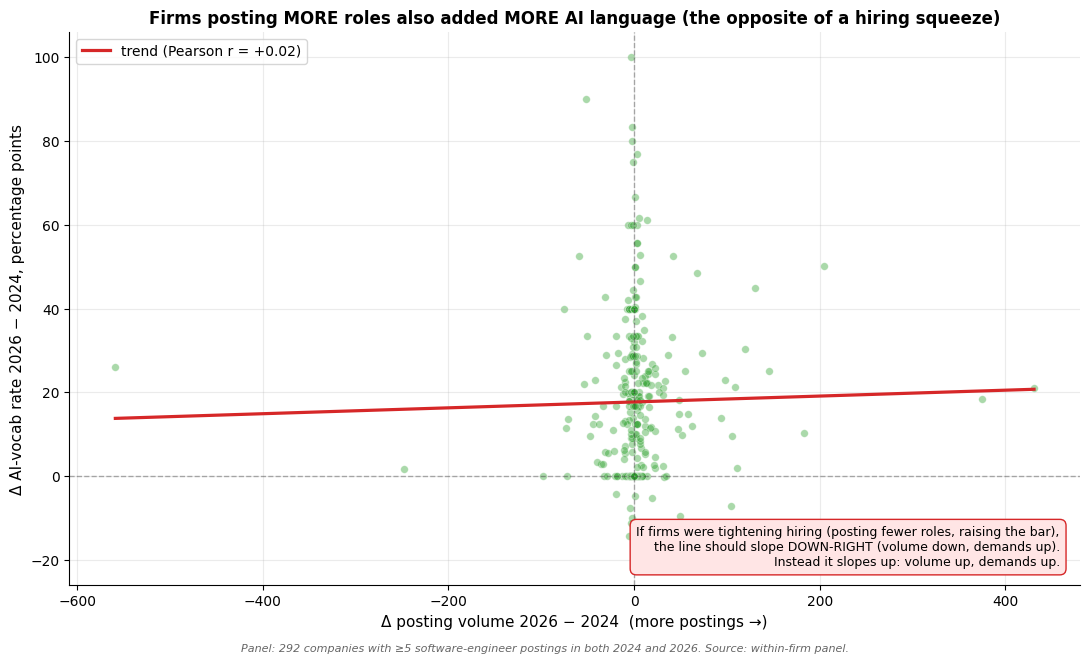

In [16]:
fig = viz_disproven_selectivity(); plt.show()

---

# Two longer articles

The findings above are single-claim sections. The two articles below synthesise multiple findings into longer pieces — each centred on one strong claim with two supporting panels.

## Article A · Coding tools democratised; agentic vocabulary did not

Headline 4 told us *which* AI tools employers are naming. This article asks *where* they are naming them — the geography, the industries, and the kind of language that travels with them. The single most surprising fact: the diffusion is asymmetric. Coding tools (GitHub Copilot, RAG, prompt engineering, MLOps) appear at *higher* rates in non-hub metros than in the Bay Area; frontier-platform vocabulary (agentic, AI agent, LLM, foundation model) does the opposite. The popular *AI-tools-are-democratising-and-geography-no-longer-matters* claim turns out to be half right and half wrong, in a specific way.

### Panel 1 — Asymmetric token diffusion

We restricted to non-builder SWE postings (no Applied AI / ML / FDE in the title) in 2026, then computed the rate at which each AI vocabulary token appears, separately in the five tech hubs (Bay, Seattle, NYC, Austin, Boston) and in the rest of the country. To rule out the obvious confound that frontier labs and hyperscalers concentrate in hubs and write their own product names, we excluded 17 such firms (OpenAI, Anthropic, Microsoft, Google, Meta, Amazon, GitHub, NVIDIA, Adobe, Salesforce, Databricks, and several frontier startups) and recomputed.

The pattern survives — and on most tokens, strengthens.

- **Hub-leading (architectural / platform vocabulary).** `agentic` +5.1 pp · `llm` +3.2 pp · `ai agent` +2.9 pp · `foundation model` +0.3 pp. These are the words people use to describe how AI is being *built into* products. They concentrate in tech-hub postings.
- **Rest-leading (coding-tool / MLOps vocabulary).** `copilot` −6.7 pp · `github copilot` −4.6 pp · `prompt engineering` −5.7 pp · `RAG` −3.9 pp · `MLOps` −4.1 pp · `claude` −1.8 pp. These are the words people use to describe AI tools that engineers *use*. They concentrate outside tech hubs.

The asymmetry is striking once self-mention contamination is stripped. The most-adopted coding tools — Copilot above all — are now more common in postings from Cleveland, Charlotte, and Tampa than from San Francisco. Architectural vocabulary about agents and model platforms has not made the same trip. (Note that `openai` as a plain token disappears as a hub-leading signal once you remove self-mentions from OpenAI, Microsoft and Google's own postings — we drop it from the list above.)

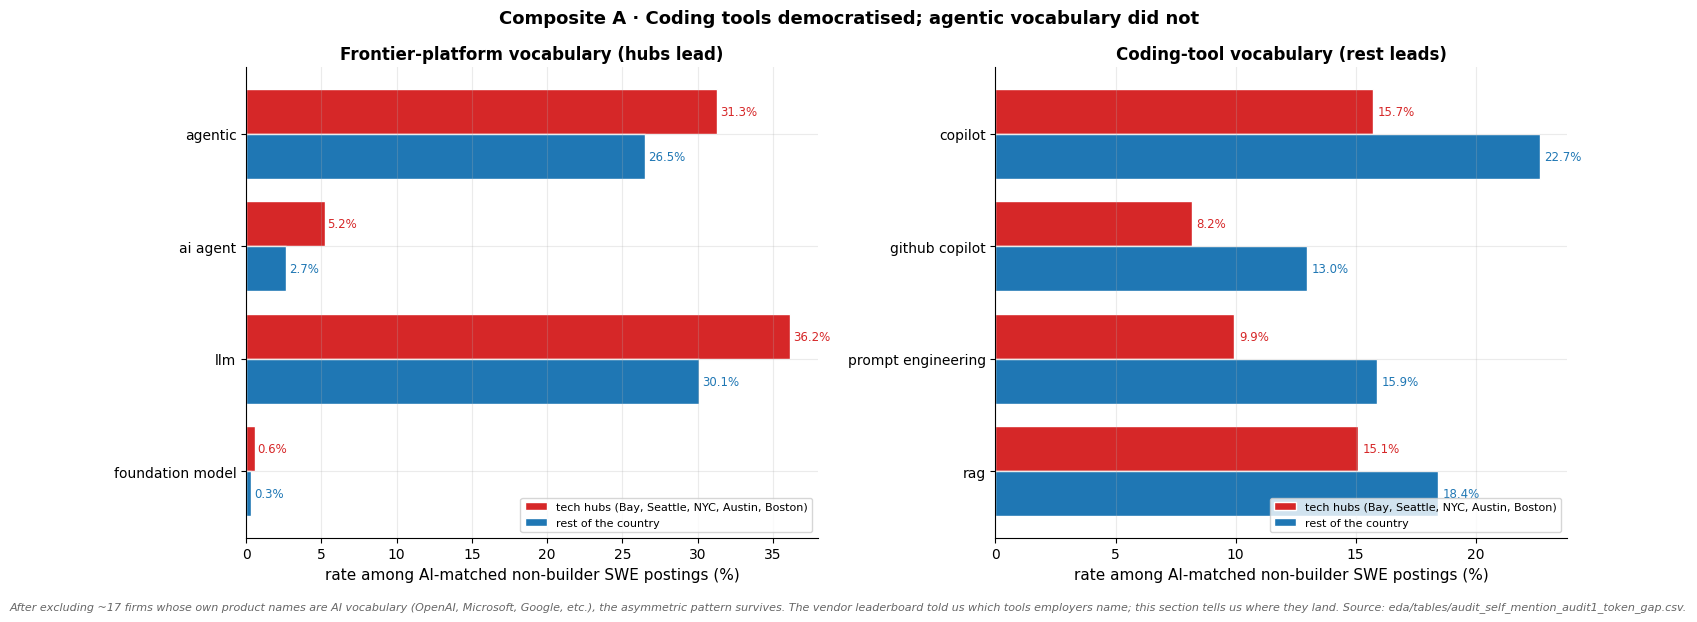

In [17]:
fig = viz_composite_a_lead(); plt.show()

### Panel 2 — Where AI is being written into engineering descriptions

Every metro in our 26-city panel saw an AI-vocab rise between 2024 and 2026, in a band of +14 to +33 pp on the broad pattern. The *absolute* 2026 rate ranks the metros differently from the *delta*. On the absolute level the Bay Area still leads (around 32% under cleaned descriptions); on the rate of change Tampa, Atlanta, and Salt Lake City share the top of the table with Seattle and the Bay. The leaderboard below shows the absolute 2026 ranking; the Sun Belt cities are climbing fastest, but not because the hubs are slowing — both are accelerating, and the Sun Belt is starting from a lower base.

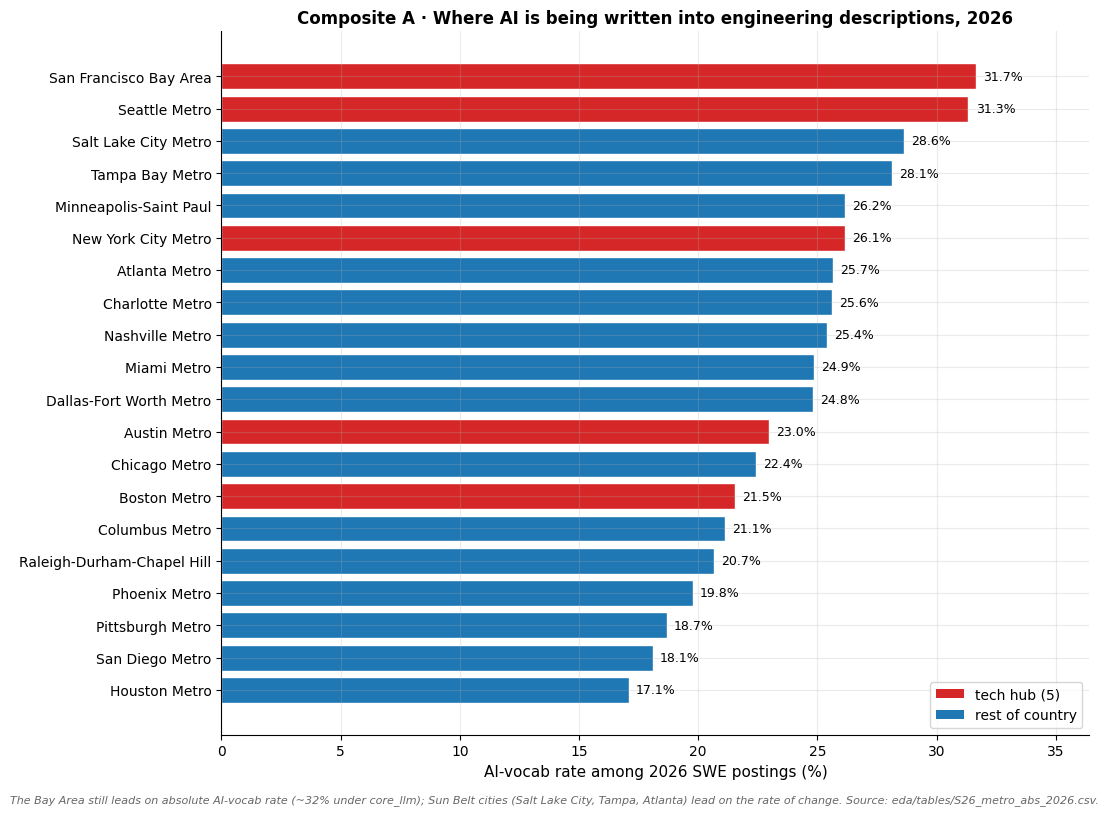

In [18]:
fig = viz_composite_a_geo(); plt.show()

### Panel 3 — Hospitals at parity with software firms

Within 2026, hospital-classified SWE postings mention AI vocabulary at roughly the same rate as software firms (32.3% vs 28.0% under cleaned descriptions, with confidence intervals that nearly touch). The story behind the parity is that LinkedIn classifies several AI-native health-tech firms (Abridge, Ambience, Inspiren) as Hospitals because that is the customer industry, and the volume at Optum and CVS — both large health-IT operations — is high. Drop those five firms and hospitals fall to about 29%, slightly below software. Either way, the regulated-industry-lag narrative does not survive at the labour-demand layer.

Financial Services lags software by 4 to 6 percentage points depending on which AI-vocabulary dictionary one uses. The more interesting fact is qualitative: when financial firms write AI requirements, they overlay them on risk, compliance, and operations vocabulary; software firms attach the same words to agent workflows and model-building. FS is not a slower software industry — it is a different one.

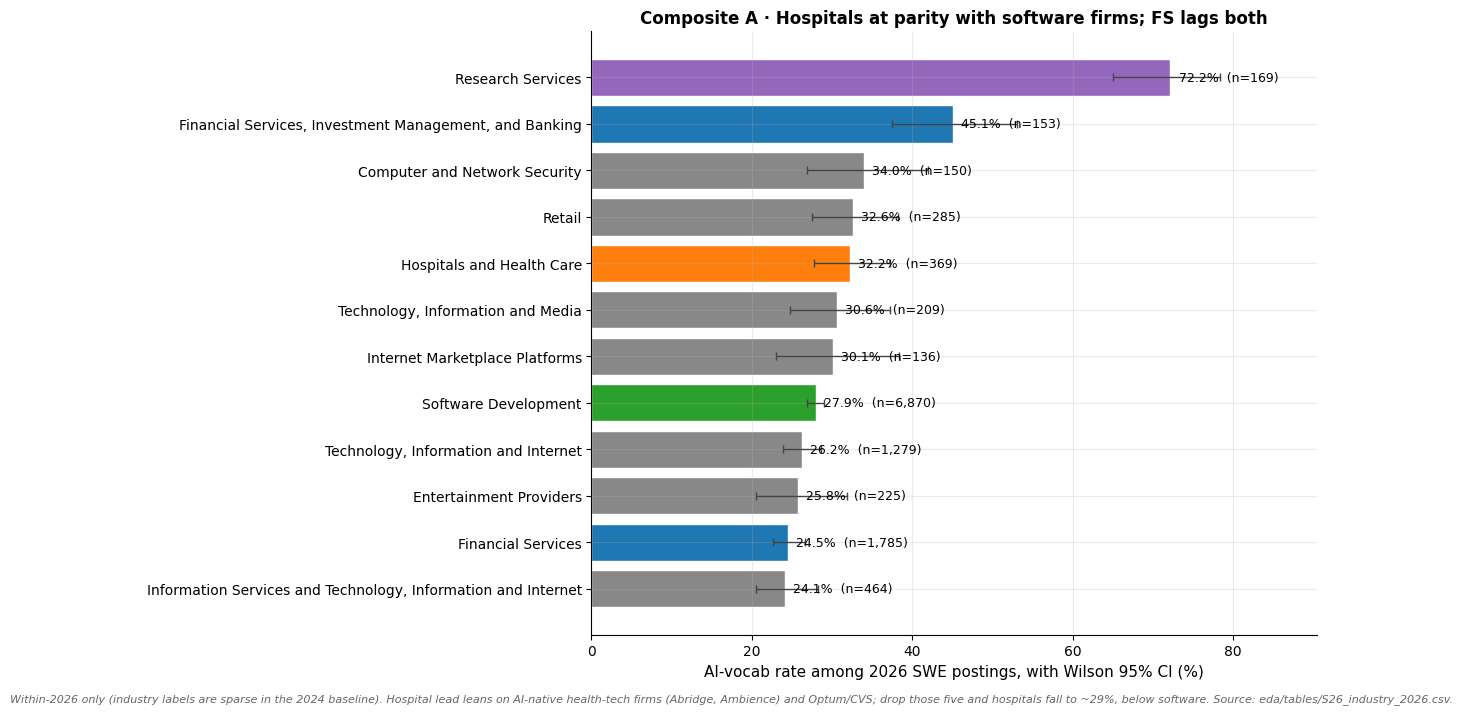

In [19]:
fig = viz_composite_a_industry(); plt.show()

### Caveats — Article A

- **Hospitals fragility.** The hospital lead leans on five firms (Optum, CVS, Abridge, HCA, Inspiren); excluding them drops the rate to roughly 29% and the headline reverses. The article frames this as parity rather than a lead.
- **LinkedIn vs BLS scope.** The geographic and industry findings are about LinkedIn's *posting frame*. BLS counts *employed* people across all hiring channels, including referrals and internal mobility that never hit a job board. The two measurements can move in different directions; we make no population-level employment claims.
- **FS-AI is qualitatively different from SWE-AI.** A spot-check of 60 financial-services AI-matched postings shows AI vocabulary embedded in compliance / risk / operations frames, not model-and-agent-building frames. The 4 to 6 pp gap is real but the substance behind those mentions is structurally different.

---

## Article B · How software-engineering roles are being created, destroyed, and rewritten

Headline 1 said the same companies are rewriting their own postings. This article asks *what* the rewrite looks like at the role level. Three things are happening at the same time. A new content cluster (RAG / agentic / LLM-systems work) has grown 5.2× as a share of the SWE corpus in two years. A new job *function*, the Forward-Deployed Engineer, has emerged at a small but high-profile set of firms. And legacy stacks (mainframe, .NET, Salesforce specialist titles) are being absorbed into modernised neighbours whose postings barely mention AI at all. Industry rhetoric describes the visible peak; the body of the change is in the rewrite and the floor.

### Panel 1 — The new specialist: an agentic-AI cluster

We embedded 37,003 SWE postings (2024 plus 2026, capped at 30 per firm-period to prevent prolific employers from dominating) and ran BERTopic. The result is a 95-topic taxonomy. The single sharpest topic is what the model labels *rag / ai_solutions / ai_systems* — and it accounts for **2.5% of 2024 SWE postings and 12.7% of 2026**, a 5.2× share rise. Within that cluster, **82% of postings mention AI vocabulary** under the cleaned-description substrate (84% under raw). The cluster is broad: Capital One, Stripe, Pinterest, Workday, Intuit, Deloitte, Synechron, and TikTok all appear in the top firms by cluster volume; frontier labs together contribute less than 2% of cluster postings, so the rise is not a self-mention artifact (a separate audit confirms the multiplier moves from 5.20× to 5.13× when frontier labs are excluded).

Two methodological notes. First, the cluster geometry is substrate-invariant by construction: BERTopic was fit on the cleaned descriptions, so cluster *membership* and *share* don't shift between substrates. The within-cluster AI-vocab rate moves modestly (84% → 82% under core_llm). Second, an independent NMF decomposition on the same texts converges on the same growth lane: NMF Topic 1 (top terms: ai, agentic, agents, rag, llm) rises from 143 to 1,785 postings (12.4× in volume terms, with borderline backend roles aggregated more loosely than HDBSCAN does). The two-method agreement is the panel's strongest methodological asset.

*Cross-reference.* Headline 4 told us which dev-tool brands employers are naming; this panel tells us which kind of work those brand mentions describe.

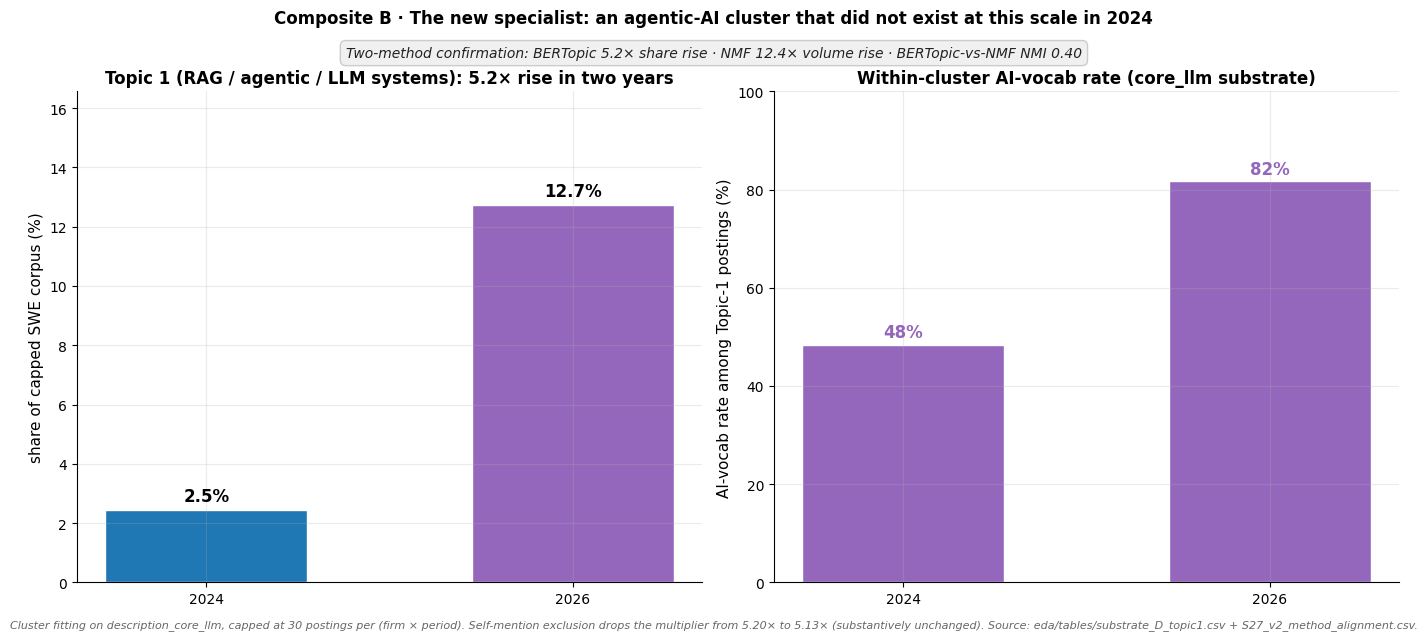

In [20]:
fig = viz_composite_b_cluster(); plt.show()

### Panel 2 — A new function (FDE) and a quiet substitution (legacy)

The **Forward-Deployed Engineer** is a Palantir-coined title that has been adopted in 2026 by OpenAI, Adobe, AMD, PhysicsX, TRM Labs, Saronic, Foxglove, Ramp, and PwC, among others. By title-or-JD-text match the count grew from 6 postings in 2024 to 130 in 2026; AI density inside FDE postings is roughly twice the general SWE rate (48% vs 24% under cleaned descriptions; the ratio is actually slightly *larger* under cleaned descriptions, because general SWE has proportionally more boilerplate-borne false positives). The base is small enough that we lead with the firm list rather than the count: the news is the function being adopted, not the labour-market scale.

The opposite story is the **legacy substitution**. Disappearing 2024 titles (Java architect, Drupal specialist, PHP architect) re-route in 2026 to nearest-neighbour titles (Java developer, DevOps engineer, web developer) whose AI mention rate is **8.9% under cleaned descriptions, vs the 23.8% market average**. The substitution flows toward stack modernisation — Postgres, CI/CD, Terraform, Kubernetes — not toward AI-ification. Mainframe developer 66 → 2 in two years; C# / .NET developer 120 → 0; Salesforce developer 45 → 5. These are real labour-demand displacements that aren't registered as "AI replacing jobs" because the substitute roles are not AI-flavoured.

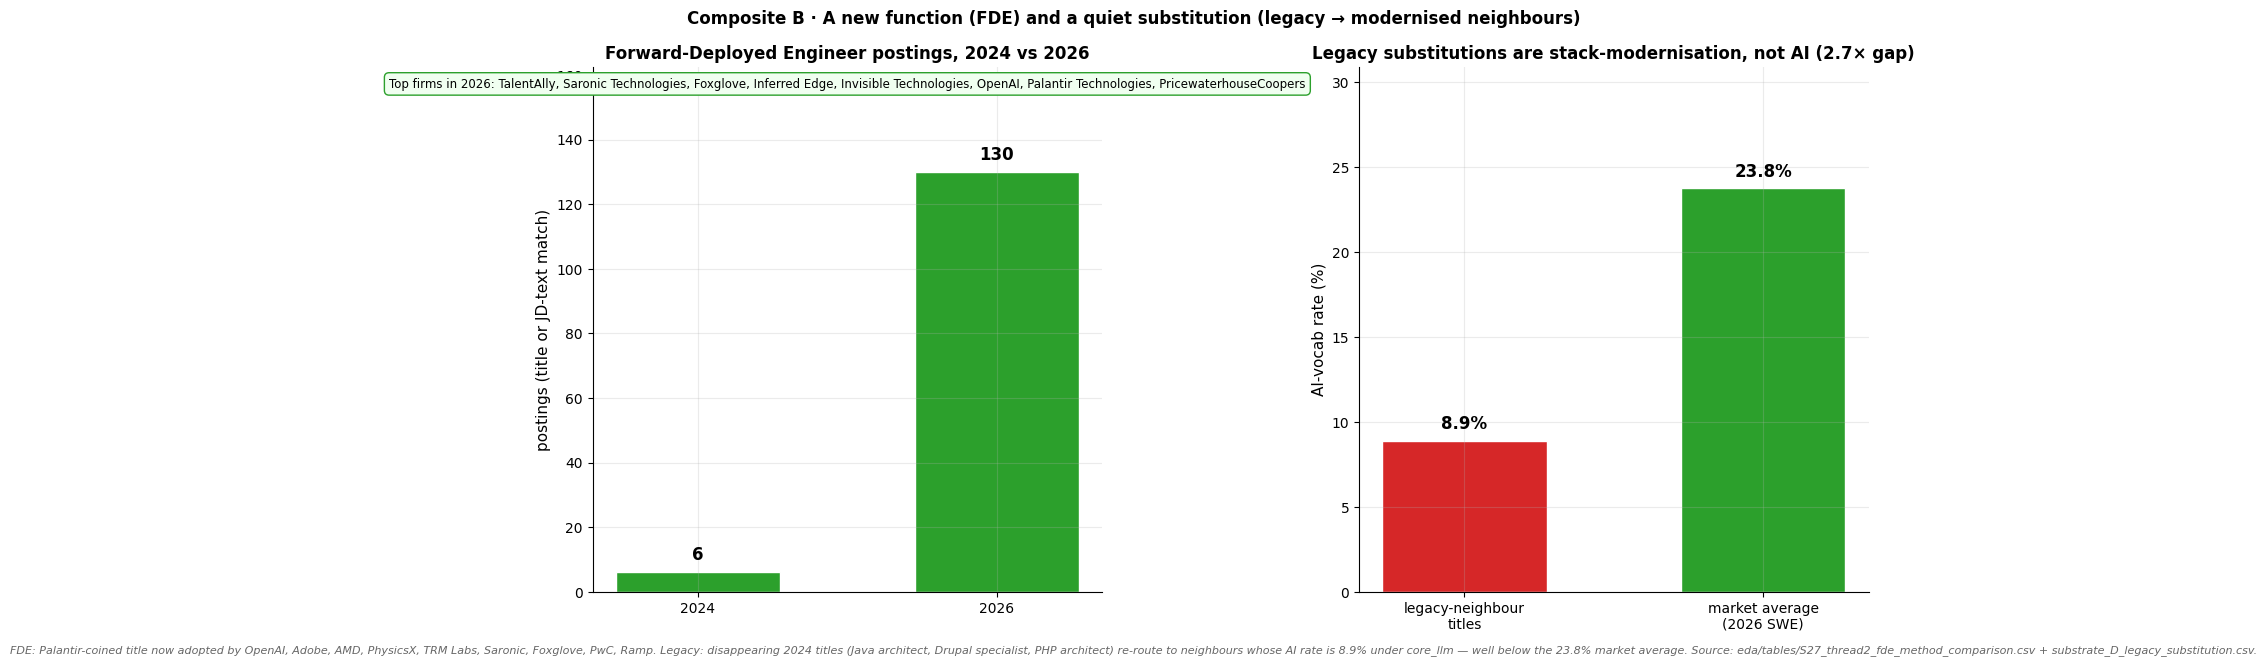

In [21]:
fig = viz_composite_b_fde_legacy(); plt.show()

### Methods footnote — Article B

BERTopic was fit on `description_core_llm` with a COALESCE fallback to raw description, on rows where `llm_extraction_coverage = 'labeled'` and length ≥ 200 characters. The sample was capped at 30 postings per `(company_name_canonical, period_bucket)` to prevent prolific employers from dominating cluster centroids. Embeddings: sentence-transformers `all-MiniLM-L6-v2`, batch 256. Clustering: UMAP (n_neighbors=15, n_components=5, cosine) + HDBSCAN (min_cluster_size=35, min_samples=10). Stability: three seeds, mean pairwise ARI = 0.64. The NMF comparator uses TF-IDF (ngram 1-2, min_df=20, max_features=30,000) and k=20. BERTopic-vs-NMF NMI on cluster assignments = 0.40. Full method specification: `eda/scripts/S27_v2_bertopic.py`.

---

# All findings on one page

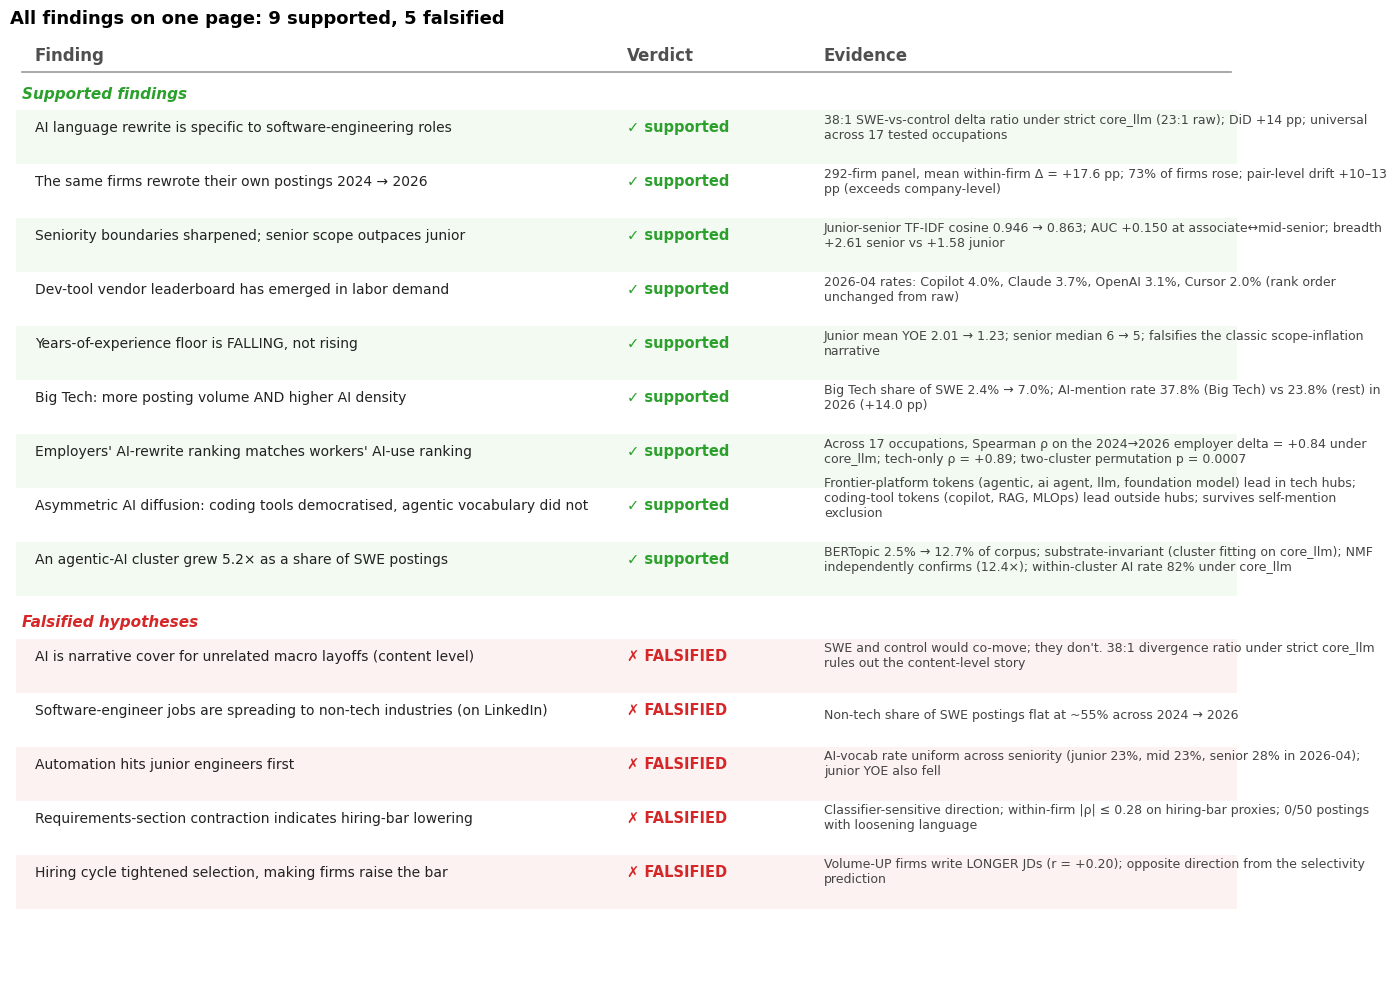

In [22]:
fig = viz_verdict_table(); plt.show()

---

## Other 2026 observations

Things that don't rise to "headline" but are worth calling out:

- **The AI rise is geographically uniform, not tech-hub-driven.** The 26 metros we track all saw AI-vocab rates climb 14 to 33 pp in SWE postings on the broad pattern. The Sun Belt cities (Tampa, Atlanta, Salt Lake City) are climbing fastest in *delta* terms; the Bay still leads on the *absolute* 2026 rate. See Article A.
- **Descriptions got longer, but the new length is boilerplate.** Benefits sections grew 89%, legal/EEO 80%, responsibilities 49%. Requirements sections were roughly flat. Length growth is mostly recruiter-editor inflation, not demand for more work.
- **Legacy roles are being replaced by modern-stack roles, not by AI roles.** Disappearing 2024 titles (Java architect, Drupal specialist, PHP architect) map to 2026 neighbors that average **8.9% AI-vocab rate** under cleaned descriptions, well below the **24% market average**. The substitution is stack-modernisation (Postgres, CI/CD, Terraform), not AI-ification. See Article B Panel 2 for the full treatment.
- **Staffing firms post cleaner descriptions than direct employers.** Ghost-score and inflation concentrate at direct employers, not aggregators, the reverse of the common intuition.
- **GitHub Copilot appears in only 0.10% of postings**, despite a roughly 33% regular-use rate in industry benchmarks. Employers do not formalize even the most-adopted AI tool as a written requirement.
- **LLM-authorship affects JD length but not JD content.** The roughly 1,100-character description growth is about half attributable to recruiters drafting with LLMs. However, AI-mention, credential stacking, scope broadening, and CI/CD increases persist at 80% to 130% of full-corpus magnitude when the most LLM-styled postings are excluded. The content shift is real, not a style artifact.
- **AI-focused senior roles ask for more experience, not less.** The emergent "Applied-AI Engineer" archetype has median YOE 6, one year above other senior archetypes. AI-era senior work is compressing into a more explicit high-experience bar, not democratizing.

## Limitations

- **LinkedIn-only sample.** No Indeed or niche-board sensitivity in this analysis. The LinkedIn-specific findings are about LinkedIn composition, which may not mirror the total US software labor market.
- **Date granularity is too coarse** to test specific AI-release windows. We can compare 2024 to 2026 but can't pinpoint ChatGPT (Nov 2022) versus Claude Code (Feb 2025) lead/lag effects.
- **Vendor-specific regexes may over-match.** "Cursor" is also UI vocabulary; "Claude" is a common name; "Llama" is a nature word. Vendor rates should be read directionally, not as precise penetration numbers.
- **The within-firm panel requires at least 5 postings in both periods.** 292 firms is meaningful but excludes most small employers.
- **LLM-YOE coverage is about 78%** of in-frame SWE rows. Possible selection bias on rows where the LLM declined to extract.
- **Cross-occupation rank correlation (Headline 7) leans on the tech-vs-non-tech split.** Within the six control occupations the rank correlation is +0.41 with a CI that crosses zero. The headline +0.83 on the 2024→2026 delta is real but should not be read as fine-grained alignment within the control side.
- **No significance tests on the headline rates themselves.** Descriptive analysis only. Formal hypothesis-testing with corrected standard errors is pending.

### Robustness: sampling-frame sensitivity

The 110,000-posting analysis file is a balanced 40/30/30 software-engineer / software-adjacent / control sample, not a natural LinkedIn distribution. You might reasonably worry that the findings above are sampling artifacts. They are not. Every rate-based claim was re-run on the full unbalanced corpus (about 1.45 million postings, LinkedIn only) and produced essentially the same numbers. The largest absolute difference on headline rates is under one percentage point, and the within-firm rewrite signal is actually *stronger* on the natural data (356 companies with mean +20.7 pp versus 292 with +17.6 pp on the balanced sample under cleaned descriptions).

### Robustness: substrate sensitivity

Every AI-vocab rate above is computed on `description_core_llm`, the LLM-stripped substrate that drops EEO / benefits / company-marketing boilerplate. A separate audit (`eda/research_memos/substrate_sensitivity.md`) recomputes every headline against the raw `description` text and reports the delta. The pattern: within-firm and within-cluster numbers are essentially substrate-invariant (boilerplate cancels in deltas); single-shot prevalence rates fall by 3 to 5 pp under cleaned descriptions; the SWE-vs-control ratio actually *strengthens* under cleaned descriptions because controls have proportionally more boilerplate-borne false positives. No headline flips. The appendix in any published version of this work should carry the raw-substrate equivalent of every rate-based claim.

## Where to dig deeper

- **Methodology protocol** (substrate, regex, sample, self-mention rules; the load-bearing decision document for this notebook): [`../research_memos/methodology_protocol.md`](../research_memos/methodology_protocol.md)
- **Substrate sensitivity audit** (raw vs cleaned descriptions, every headline): [`../research_memos/substrate_sensitivity.md`](../research_memos/substrate_sensitivity.md)
- **Headline 7 audit** (cross-occupation rank correlation, permutation nulls, jackknife): [`../research_memos/claim7_evaluation.md`](../research_memos/claim7_evaluation.md)
- **Article A deep dive** (hospitals, FS-vs-SWE, Bay-vs-rest tokens): [`../research_memos/composite_A_deepdive.md`](../research_memos/composite_A_deepdive.md)
- **Article B v2** (BERTopic rerun, NMF comparator, FDE, legacy): [`../research_memos/composite_B_v2.md`](../research_memos/composite_B_v2.md)
- **Self-mention contamination audit** (frontier-lab self-mentions vs the actual diffusion signal): [`../research_memos/self_mention_audit.md`](../research_memos/self_mention_audit.md)
- **v9 methodology audit** (regex precision, alternative patterns): [`../research_memos/v9_methodology_audit.md`](../research_memos/v9_methodology_audit.md)
- **Working analysis notebook** with every underlying DuckDB query: [`open_ended_v2.ipynb`](open_ended_v2.ipynb)
- **Project research design**: [`../../docs/1-research-design.md`](../../docs/1-research-design.md)
- **Interview protocol** for the qualitative follow-up: [`../../docs/2-interview-design-mechanisms.md`](../../docs/2-interview-design-mechanisms.md)